Dataset Shape:
(7043, 21)

First Five Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stre

C:\Users\taurm\AppData\Local\Temp\ipykernel_16036\2330078866.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocess


Logistic Regression CV Accuracy:
[0.82608696 0.80301686 0.80124224 0.79946761 0.78507993]
Mean CV Accuracy: 0.8029787187096632


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Random Forest CV Accuracy:
[0.7985803  0.79946761 0.78438332 0.7755102  0.77797513]
Mean CV Accuracy: 0.7871833141318926

Logistic Regression
Accuracy : 0.797
Precision: 0.6358
Recall   : 0.5508
F1 Score : 0.5903
ROC-AUC  : 0.8407

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest
Accuracy : 0.7921
Precision: 0.6373
Recall   : 0.5027
F1 Score : 0.562
ROC-AUC  : 0.8225

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       

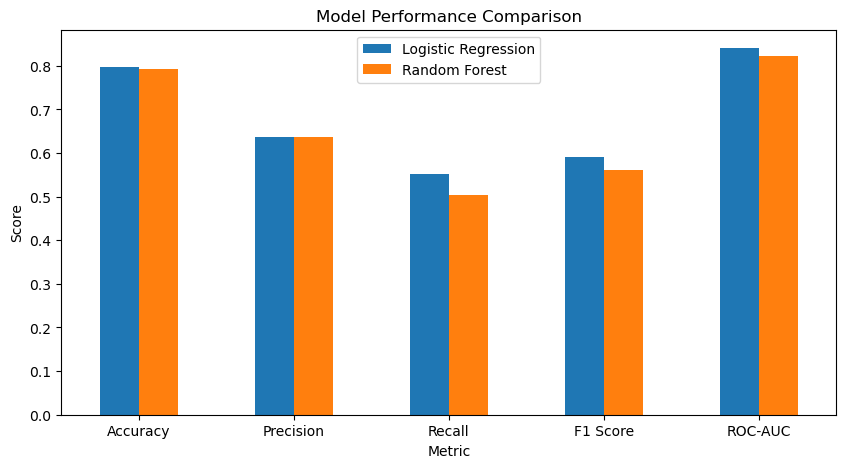

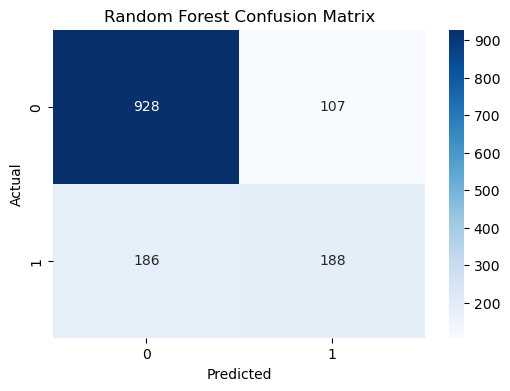

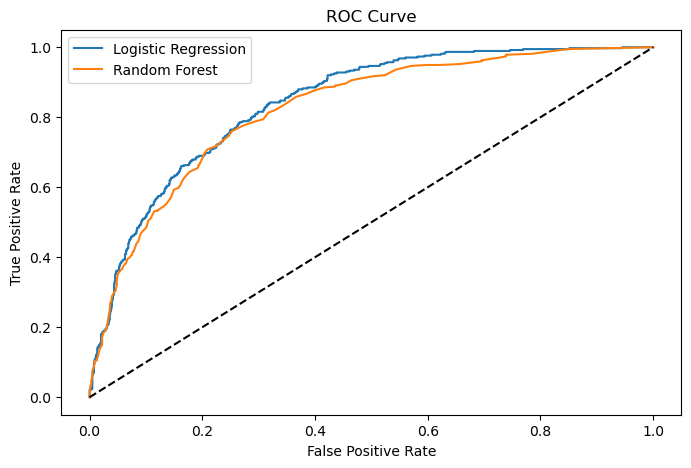


Best Model: Logistic Regression


In [2]:
# ============================================================
# CUSTOMER CHURN PREDICTION USING MACHINE LEARNING
# ============================================================

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
print(df.head())

# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

# Remove Customer ID

df.drop("customerID", axis=1, inplace=True)

# Encode categorical variables

encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print("\nData after Encoding:")
print(df.head())

# ============================================================
# 4. FEATURES AND TARGET
# ============================================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

# ============================================================
# 5. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(max_iter=1000)

# Cross Validation

cv_lr = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\nLogistic Regression CV Accuracy:")
print(cv_lr)
print("Mean CV Accuracy:", cv_lr.mean())

# Train Model

lr.fit(X_train, y_train)

# Predictions

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# ============================================================
# 7. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Cross Validation

cv_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\nRandom Forest CV Accuracy:")
print(cv_rf)
print("Mean CV Accuracy:", cv_rf.mean())

# Train Model

rf.fit(X_train, y_train)

# Predictions

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# ============================================================
# 8. EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC-AUC  :", round(roc_auc,4))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    return [accuracy, precision, recall, f1, roc_auc]

# ============================================================
# 9. MODEL EVALUATION
# ============================================================

lr_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

# ============================================================
# 10. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Metric":
    ["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],

    "Logistic Regression":
    lr_metrics,

    "Random Forest":
    rf_metrics
})

print("\nModel Comparison:")
print(comparison)

# ============================================================
# 11. BAR CHART COMPARISON
# ============================================================

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 13. ROC CURVE
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# ============================================================
# 14. FINAL MODEL SELECTION
# ============================================================

if rf_metrics[4] > lr_metrics[4]:
    print("\nBest Model: Random Forest")
else:
    print("\nBest Model: Logistic Regression")